# Projet d'Analyse de données



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from skimpy import skim
#import seaborn as sns 
%matplotlib inline

## Introduction


## Présentation du jeu de données 

In [3]:
# Liste des variables originales et leurs descriptions
variables = {
    "Date": "Date du jour de la donnée",
    "Service": "Type de service ou train",
    "Gare de départ": "Gare de départ",
    "Gare d'arrivée": "Gare d'arrivée",
    "Durée moyenne du trajet": "Durée moyenne du trajet",
    "Nombre de circulations prévues": "Nombre de circulations prévues",
    "Nombre de trains annulés": "Nombre de trains annulés",
    "Nombre de trains en retard au départ": "Nombre de trains en retard au départ",
    "Retard moyen des trains en retard au départ": "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ": "Retard moyen de tous les trains au départ",
    "Nombre de trains en retard à l'arrivée": "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée": "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée": "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min": "Nombre de trains en retard de plus de 15 min",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "Retard moyen > 15 min si concurrence aérienne",
    "Nombre trains en retard > 30min": "Nombre de trains en retard de plus de 30 min",
    "Nombre trains en retard > 60min": "Nombre de trains en retard de plus de 60 min",
    "Prct retard pour causes externes": "Pourcentage de retard pour causes externes",
    "Prct retard pour cause infrastructure": "Pourcentage de retard pour causes infrastructure",
    "Prct retard pour cause gestion trafic": "Pourcentage de retard pour causes gestion trafic",
    "Prct retard pour cause matériel roulant": "Pourcentage de retard pour causes matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "Pourcentage de retard pour causes gestion gare / réutilisation matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence": "Pourcentage de retard pour causes affluence voyageurs"
}

# transformer noms plus courts
short_names = {
    "Date": "date",
    "Service": "service",
    "Gare de départ": "dep_station",
    "Gare d'arrivée": "arr_station",
    "Durée moyenne du trajet": "avg_duration",
    "Nombre de circulations prévues": "planned_trains",
    "Nombre de trains annulés": "cancelled_trains",
    "Nombre de trains en retard au départ": "dep_late_trains",
    "Retard moyen des trains en retard au départ": "dep_avg_late",
    "Retard moyen de tous les trains au départ": "dep_avg_all",
    "Nombre de trains en retard à l'arrivée": "arr_late_trains",
    "Retard moyen des trains en retard à l'arrivée": "arr_avg_late",
    "Retard moyen de tous les trains à l'arrivée": "arr_avg_all",
    "Nombre trains en retard > 15min": "late_15",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "late_15_air",
    "Nombre trains en retard > 30min": "late_30",
    "Nombre trains en retard > 60min": "late_60",
    "Prct retard pour causes externes": "pct_external",
    "Prct retard pour cause infrastructure": "pct_infra",
    "Prct retard pour cause gestion trafic": "pct_traffic",
    "Prct retard pour cause matériel roulant": "pct_rolling",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "pct_station",
    "Prct retard pour cause prise en compte voyageurs (affluence": "pct_passengers"
}

# création DataFrame pour affichage 
df_vars = pd.DataFrame({
    "Variables renommées": [short_names[k] for k in variables.keys()],
    "Description": [variables[k] for k in variables.keys()]
})

print("Chaque individu représente un mois, pour lesquels on observe 23 variables")
display(df_vars.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'left')])]
))

#attention, je n'ai pas mis les 5 colonnes qui ont beaucoup de données manquantes
#a adapter quand nettoyage données est fait 

Chaque individu représente un mois, pour lesquels on observe 23 variables


,Variables renommées,Description
0,date,Date du jour de la donnée
1,service,Type de service ou train
2,dep_station,Gare de départ
3,arr_station,Gare d'arrivée
4,avg_duration,Durée moyenne du trajet
5,planned_trains,Nombre de circulations prévues
6,cancelled_trains,Nombre de trains annulés
7,dep_late_trains,Nombre de trains en retard au départ
8,dep_avg_late,Retard moyen des trains en retard au départ
9,dep_avg_all,Retard moyen de tous les trains au départ


## Prise en charge des données


In [4]:
data = pd.read_excel('regularite-mensuelle-tgv-aqst.ods',engine='odf')
data = data.rename(columns=short_names)


display( 
    data.head().style.background_gradient(cmap='BuPu')
)

ModuleNotFoundError: No module named 'odf.opendocument'

In [5]:
cols_to_drop = [
    c for c in data.columns 
    if c.startswith("Commentaire") 
    or " gestions PSH" in c 
    or "correspondances)" in c
]
data = data.drop(columns=cols_to_drop)
display(
    data.head().style.background_gradient(cmap="BuPu")
)
len(data)

data['date'] = data['date'].astype('category')
data['service'] = data['service'].astype('category')
data['dep_station'] = data['dep_station'].astype('category')
data['arr_station'] = data['arr_station'].astype('category')
skim(data)

NameError: name 'data' is not defined

## Exploration élémentaire : analyse descriptive

### Analyse descriptive unidimensionnelles

#### Pourcentage moyen de retard en fonction des causes 

In [67]:
#calcule le % moyen de retard pour causes externes
external_mean = data['pct_external'].mean()
print(f"Pourcentage moyen de retard pour causes externes: {external_mean:.2f}%")

#calcule le % moyen de retard pour causes infrastruture
infrastruture_mean = data['pct_infra'].mean()
print(f"Pourcentage moyen de retard pour causes infrastruture: {infrastruture_mean:.2f}%")

#calcule le % moyen de retard pour causes gestion traffic
traffic_mean = data['pct_traffic'].mean()
print(f"Pourcentage moyen de retard pour causes gestion traffic: {traffic_mean:.2f}%")

#calcule le % moyen de retard pour causes matériel roulant
rolling_mean = data['pct_rolling'].mean()
print(f"Pourcentage moyen de retard pour causes matériel roulant: {rolling_mean:.2f}%")

#calcule le % moyen de retard pour causes gestion gare / réutilisation matériel
station_mean = data['pct_station'].mean()
print(f"Pourcentage moyen de retard pour causes gestion gare / réutilisation matériel: {station_mean:.2f}%")

#calcule le % moyen de retard pour causes prise en compte voyageurs (affluence)
passengers_mean = data['pct_passengers'].mean()
print(f"Pourcentage moyen de retard pour causes prise en compte voyageurs (affluence): {passengers_mean:.2f}%")

Pourcentage moyen de retard pour causes externes: 19.42%
Pourcentage moyen de retard pour causes infrastruture: 22.09%
Pourcentage moyen de retard pour causes gestion traffic: 23.28%
Pourcentage moyen de retard pour causes matériel roulant: 18.00%
Pourcentage moyen de retard pour causes gestion gare / réutilisation matériel: 8.56%
Pourcentage moyen de retard pour causes prise en compte voyageurs (affluence): 7.73%


#### Min Max et Médiane 

In [84]:
# Liste des colonnes pour les causes de retard
causes = ['pct_external', 'pct_infra', 'pct_traffic', 'pct_rolling', 'pct_station', 'pct_passengers']

# Parcours de chaque cause pour afficher min, médiane et max
for cause in causes:
    min_val = data[cause].min()
    median_val = data[cause].median()
    max_val = data[cause].max()
    print(f"{cause}: min = {min_val:.2f}%, médiane = {median_val:.2f}%, max = {max_val:.2f}%")

pct_external: min = 0.00%, médiane = 17.39%, max = 100.00%
pct_infra: min = 0.00%, médiane = 20.69%, max = 100.00%
pct_traffic: min = 0.00%, médiane = 22.22%, max = 100.00%
pct_rolling: min = 0.00%, médiane = 16.35%, max = 100.00%
pct_station: min = 0.00%, médiane = 7.21%, max = 66.67%
pct_passengers: min = 0.00%, médiane = 6.45%, max = 66.67%


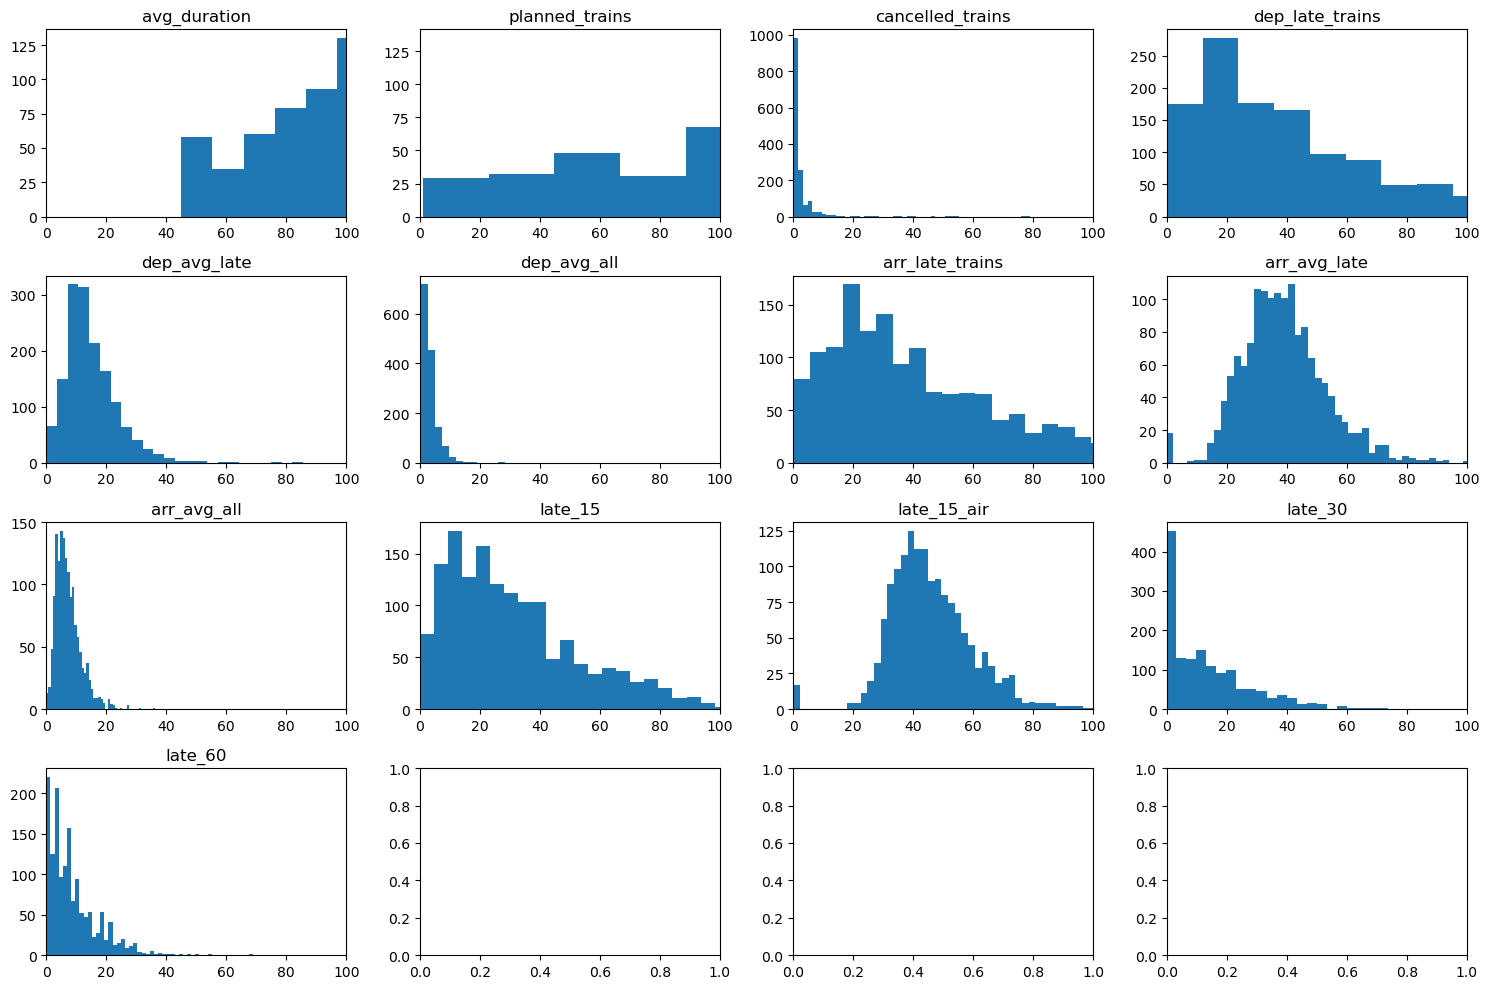

In [41]:
fig, axes = plt.subplots(4, 4, figsize=(15, 10))

columns = ["avg_duration", "planned_trains", "cancelled_trains","dep_late_trains", "dep_avg_late", "dep_avg_all", "arr_late_trains", "arr_avg_late", "arr_avg_all", "late_15", "late_15_air", "late_30", "late_60"]
axes_flat = axes.flatten()

for i, col in enumerate(columns):
    axes_flat[i].set_xlim(0, 100)
    axes_flat[i].hist(data[col], bins=50)
    axes_flat[i].set_title(col)


plt.tight_layout()
plt.show()

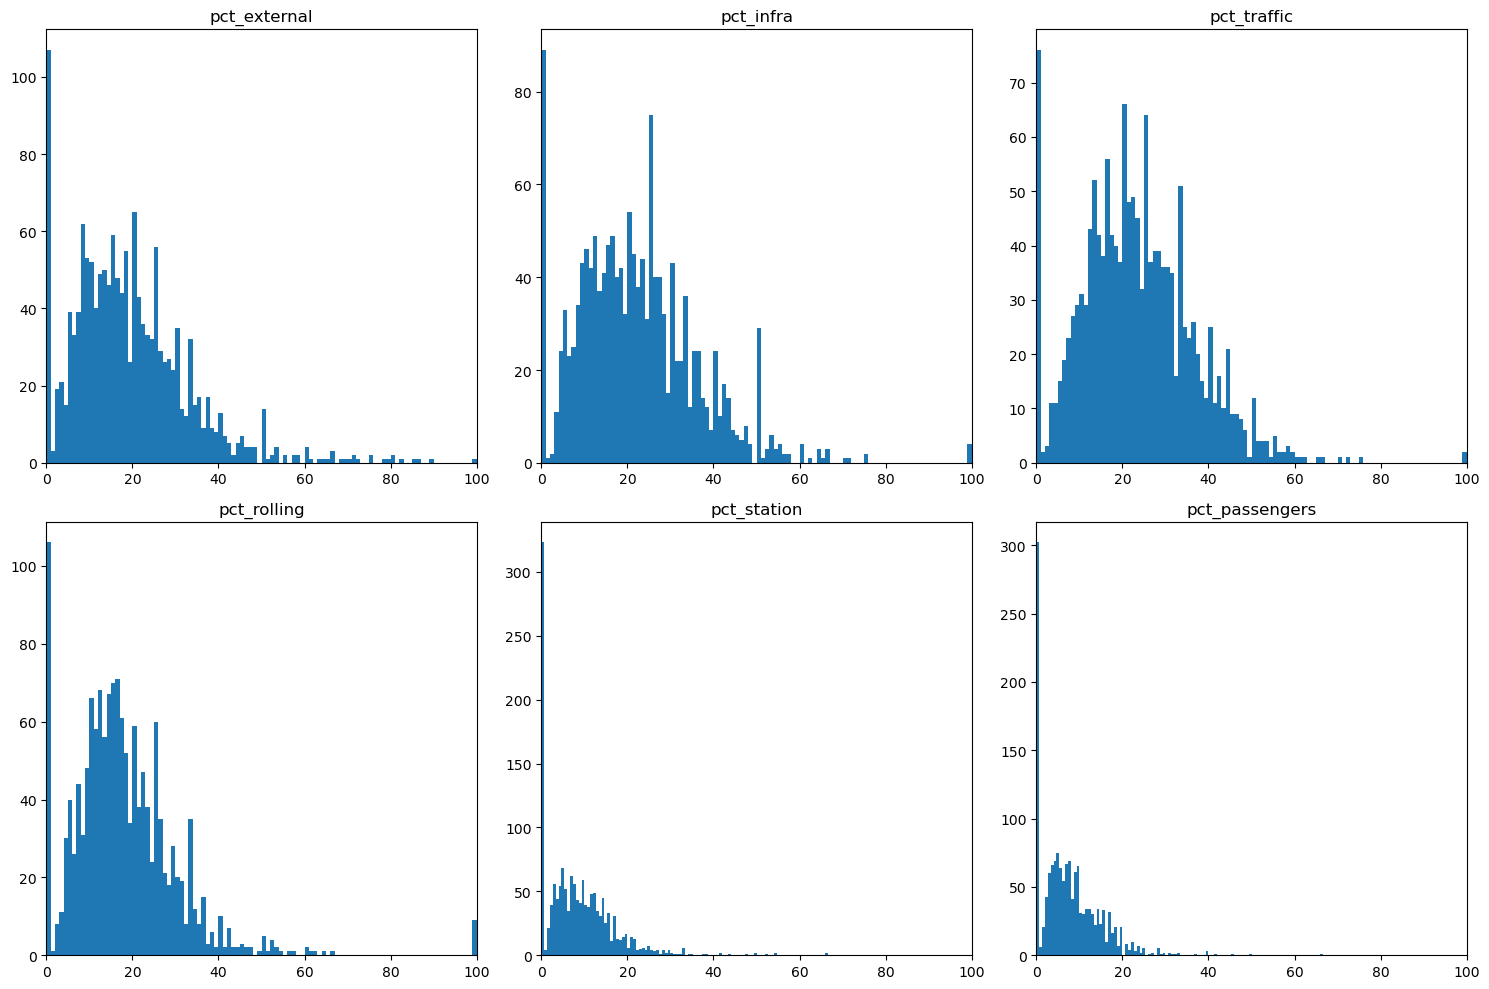

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

columns = ["pct_external", "pct_infra", "pct_traffic","pct_rolling", "pct_station", "pct_passengers"]
axes_flat = axes.flatten()

for i, col in enumerate(columns):
    axes_flat[i].set_xlim(0, 100)
    axes_flat[i].hist(data[col], bins=100)
    axes_flat[i].set_title(col)


plt.tight_layout()
plt.show()

In [87]:
summary_stats = data.describe()
print("Descriptive Statistics Summary:")
print(summary_stats)

Descriptive Statistics Summary:
       avg_duration  planned_trains  cancelled_trains  \
count    1505.00000     1505.000000       1505.000000   
mean      171.40000      291.059136          2.227243   
std        88.05765      195.116884          5.439481   
min        45.00000        1.000000          0.000000   
25%        99.00000      163.000000          0.000000   
50%       162.00000      238.000000          1.000000   
75%       226.00000      402.000000          2.000000   
max       564.00000     1097.000000         79.000000   

       Commentaire annulations  dep_late_trains  dep_avg_late  dep_avg_all  \
count                      0.0      1505.000000   1505.000000  1505.000000   
mean                       NaN        79.043189     15.383588     3.595026   
std                        NaN        83.780060     11.633914     6.302019   
min                        NaN         0.000000      0.000000    -1.964072   
25%                        NaN        20.000000      9.101852   

In [89]:
Pour chaque variable on a :
nombre de lignes
moyenne
l écart type
minimum
les trois quartiles
maximum

SyntaxError: invalid syntax (3579356489.py, line 1)

### Analyse descriptive bidimensionnelles


### ACP